In [1]:
!pip install seaborn
!pip install scipy


## Importações 


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import *
import warnings


# Configurações de visualização
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')


✅ Bibliotecas carregadas com sucesso!
   NumPy   : 2.2.6
   Pandas  : 2.3.3
   Seaborn : 0.13.2


## Geração do Dataset Simulado de Medidores 



In [10]:
np.random.seed(42)

# Parâmetros da simulação
N_MEDIDORES = 50
INICIO      = '2024-01-01'
FIM         = '2024-06-30'
INTERVALO   = '1h'   

datas = pd.date_range(start=INICIO, end=FIM, freq=INTERVALO)
medidores = [f'MED_{str(i).zfill(3)}' for i in range(1, N_MEDIDORES + 1)]

registros = []
for med in medidores:
    # Perfil de consumo varia por medidor (residencial, comercial, industrial)
    perfil = np.random.choice(['Residencial', 'Comercial', 'Industrial'],
                               p=[0.6, 0.3, 0.1])
    base = {'Residencial': 1.5, 'Comercial': 4.0, 'Industrial': 12.0}[perfil]
    
    for dt in datas:
        hora  = dt.hour
        # Padrão horário: pico manhã (7-9h) e noite (18-22h)
        fator_hora = 1.0 + 0.5 * np.exp(-((hora - 8) ** 2) / 4) \
                         + 0.7 * np.exp(-((hora - 20) ** 2) / 6)
        consumo = max(0, base * fator_hora + np.random.normal(0, base * 0.15))
        registros.append({
            'medidor_id'   : med,
            'perfil'       : perfil,
            'timestamp'    : dt,
            'consumo_kwh'  : round(consumo, 4),
            'tensao_v'     : round(np.random.normal(220, 3), 2),
            'fator_potencia': round(np.clip(np.random.normal(0.92, 0.04), 0.7, 1.0), 3)
        })

df_raw = pd.DataFrame(registros)

# Injeção intencional de problemas de qualidade 
# Valores nulos aleatórios (~2%)
idx_null = df_raw.sample(frac=0.02, random_state=1).index
df_raw.loc[idx_null, 'consumo_kwh'] = np.nan

# Outliers extremos (leituras negativas / picos absurdos)
idx_out = df_raw.sample(n=120, random_state=2).index
df_raw.loc[idx_out[:60], 'consumo_kwh'] = -9.99
df_raw.loc[idx_out[60:], 'consumo_kwh'] = df_raw.loc[idx_out[60:], 'consumo_kwh'] * 15

# Duplicatas
df_duplicatas = df_raw.sample(n=80, random_state=3)
df_raw = pd.concat([df_raw, df_duplicatas], ignore_index=True)

print(f'✅ Dataset gerado: {df_raw.shape[0]:,} registros | {df_raw.shape[1]} colunas')
print(f'   Período : {INICIO} → {FIM}')
print(f'   Medidores: {N_MEDIDORES} ({df_raw.perfil.value_counts().to_dict()})')

✅ Dataset gerado: 217,330 registros | 6 colunas
   Período : 2024-01-01 → 2024-06-30
   Medidores: 50 ({np.str_('Residencial'): 130391, np.str_('Comercial'): 60862, np.str_('Industrial'): 26077})


## Inspeção Inicial

In [15]:

print(f'Shape: {df_raw.shape}')
print(f'\nPeríodo: {df_raw.timestamp.min()} → {df_raw.timestamp.max()}')
print(f'\nTipos de dados:')
print(df_raw.dtypes)
print(f'\nPrimeiros registros:')
df_raw.head()

Shape: (217330, 6)

Período: 2024-01-01 00:00:00 → 2024-06-30 00:00:00

Tipos de dados:
medidor_id                object
perfil                    object
timestamp         datetime64[ns]
consumo_kwh              float64
tensao_v                 float64
fator_potencia           float64
dtype: object

Primeiros registros:


,medidor_id,perfil,timestamp,consumo_kwh,tensao_v,fator_potencia
0,MED_001,Residencial,2024-01-01 00:00:00,1.2498,220.96,0.931
1,MED_001,Residencial,2024-01-01 01:00:00,1.7274,218.26,0.899
2,MED_001,Residencial,2024-01-01 02:00:00,1.3715,217.23,0.815
3,MED_001,Residencial,2024-01-01 03:00:00,1.7153,222.45,0.859
4,MED_001,Residencial,2024-01-01 04:00:00,1.4174,217.77,0.892


In [17]:
print('Estatísticas descritivas:')
df_raw.describe().round(3)

Estatísticas descritivas:


,timestamp,consumo_kwh,tensao_v,fator_potencia
count,217330,212986.000,217330.000,217330.000
mean,2024-03-31 12:01:12.470436608,4.156,219.997,0.920
min,2024-01-01 00:00:00,-9.990,206.830,0.741
25%,2024-02-15 06:00:00,1.651,217.970,0.893
50%,2024-03-31 12:00:00,2.226,220.000,0.920
75%,2024-05-15 18:00:00,4.719,222.020,0.947
max,2024-06-30 00:00:00,352.754,233.830,1.000
std,NaN,4.487,2.997,0.039


## Análise da Qualidade dos Dados 

In [24]:
#Função pra gerar relatorio da qualidade dos dados
def relatorio_qualidade(df: pd.DataFrame) -> pd.DataFrame:
    relatorio = []
    for coluna in df.columns:
        total    = len(df)
        nulos    = df[coluna].isna().sum()
        unicos   = df[coluna].nunique()
        duplicas = df.duplicated().sum()
        relatorio.append({
            'coluna'         : coluna,
            'tipo'           : str(df[coluna].dtype),
            'nulos'          : nulos,
            'pct_nulo'       : f'{nulos/total*100:.2f}%',
            'valores_unicos' : unicos,
            'completude'     : f'{(1 - nulos/total)*100:.2f}%'
        })
    rel = pd.DataFrame(relatorio)
    print(f'\nRegistros duplicados: {df.duplicated().sum()}')
    return rel

rel = relatorio_qualidade(df_raw)
print('\nRelatório de Qualidade dos Dados:')
rel


Registros duplicados: 80

Relatório de Qualidade dos Dados:


,coluna,tipo,nulos,pct_nulo,valores_unicos,completude
0,medidor_id,object,0,0.00%,50,100.00%
1,perfil,object,0,0.00%,3,100.00%
2,timestamp,datetime64[ns],0,0.00%,4345,100.00%
3,consumo_kwh,float64,4344,2.00%,71780,98.00%
4,tensao_v,float64,0,0.00%,2121,100.00%
5,fator_potencia,float64,0,0.00%,241,100.00%


In [29]:
# Identificar outliers com IQR
Q1 = df_raw['consumo_kwh'].quantile(0.25)
Q3 = df_raw['consumo_kwh'].quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outliers = df_raw[
    (df_raw['consumo_kwh'] < limite_inf) |
    (df_raw['consumo_kwh'] > limite_sup)
]

print(f'Análise de Outliers (método IQR):')
print(f'\nLimite inferior     : {limite_inf:.4f} kWh')
print(f'Limite superior     : {limite_sup:.4f} kWh')
print(f'Outliers encontrados: {len(outliers):,} ({len(outliers)/len(df_raw)*100:.2f}%)')
print(f'Valores negativos   : {(df_raw.consumo_kwh < 0).sum()}')

Análise de Outliers (método IQR):

Limite inferior     : -2.9507 kWh
Limite superior     : 9.3204 kWh
Outliers encontrados: 24,897 (11.46%)
Valores negativos   : 60


## Limpeza e Pré-processamento

In [31]:
df = df_raw.copy()

# Remover duplicatas
n_antes = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicatas removidas     : {n_antes - len(df):,} registros')

# Remover valores negativos (leituras inválidas) 
n_antes = len(df)
df = df[df['consumo_kwh'] >= 0]
print(f'Valores negativos removidos : {n_antes - len(df):,} registros')

# Tratar outliers extremos (Winsorização) 
p_lower = df['consumo_kwh'].quantile(0.005)
p_upper = df['consumo_kwh'].quantile(0.995)
df['consumo_kwh'] = df['consumo_kwh'].clip(lower=p_lower, upper=p_upper)
print(f'Winsorização aplicada    : [{p_lower:.3f}, {p_upper:.3f}] kWh')

# Imputar valores nulos com mediana por medidor 
nulos_antes = df['consumo_kwh'].isna().sum()
df['consumo_kwh'] = df.groupby('medidor_id')['consumo_kwh'] \
                      .transform(lambda x: x.fillna(x.median()))
print(f'Nulos imputados (mediana): {nulos_antes:,} valores')

# Engenharia de features temporais 
df['hora']       = df['timestamp'].dt.hour
df['dia_semana'] = df['timestamp'].dt.day_name()
df['mes']        = df['timestamp'].dt.month
df['turno']      = pd.cut(df['hora'],
                           bins=[-1, 5, 11, 17, 23],
                           labels=['Madrugada','Manhã','Tarde','Noite'])
df['fim_semana'] = df['timestamp'].dt.dayofweek >= 5
print(f'Features temporais criadas: hora, dia_semana, mes, turno, fim_semana')

print(f'\nDataset limpo: {len(df):,} registros | Nulos restantes: {df.consumo_kwh.isna().sum()}')

Duplicatas removidas     : 80 registros
Valores negativos removidos : 4,404 registros
Winsorização aplicada    : [1.034, 20.641] kWh
Nulos imputados (mediana): 0 valores
Features temporais criadas: hora, dia_semana, mes, turno, fim_semana

Dataset limpo: 212,846 registros | Nulos restantes: 0


## Análise Exploratória de Dados (EDA)

In [32]:
#Consumo médio por perfil 
print('Consumo médio por perfil (kWh):')
resumo_perfil = df.groupby('perfil')['consumo_kwh'].agg(['mean','std','median','count'])
resumo_perfil.columns = ['Média','Desvio Padrão','Mediana','Qtd. Registros']
resumo_perfil.round(4)

Consumo médio por perfil (kWh):


,Média,Desvio Padrão,Mediana,Qtd. Registros
perfil,,,,
Comercial,4.7952,1.1153,4.6185,59617
Industrial,14.3334,3.1090,13.8693,25512
Residencial,1.8011,0.4908,1.7328,127717


In [35]:
# Análise por turno e fim de semana 
print('Consumo médio por Turno vs Fim de Semana:')
pivot_turno = df.pivot_table(
    values='consumo_kwh', index='turno',
    columns='fim_semana', aggfunc='mean'
).rename(columns={False: 'Dias Úteis', True: 'Fim de Semana'})
pivot_turno.round(4)

Consumo médio por Turno vs Fim de Semana:


/tmp/ipykernel_9901/3178311906.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_turno = df.pivot_table(


fim_semana,Dias Úteis,Fim de Semana
turno,,
Madrugada,3.5025,3.5002
Manhã,4.4420,4.4374
Tarde,3.5967,3.5919
Noite,5.0294,5.0344


## Visualizações Analíticas

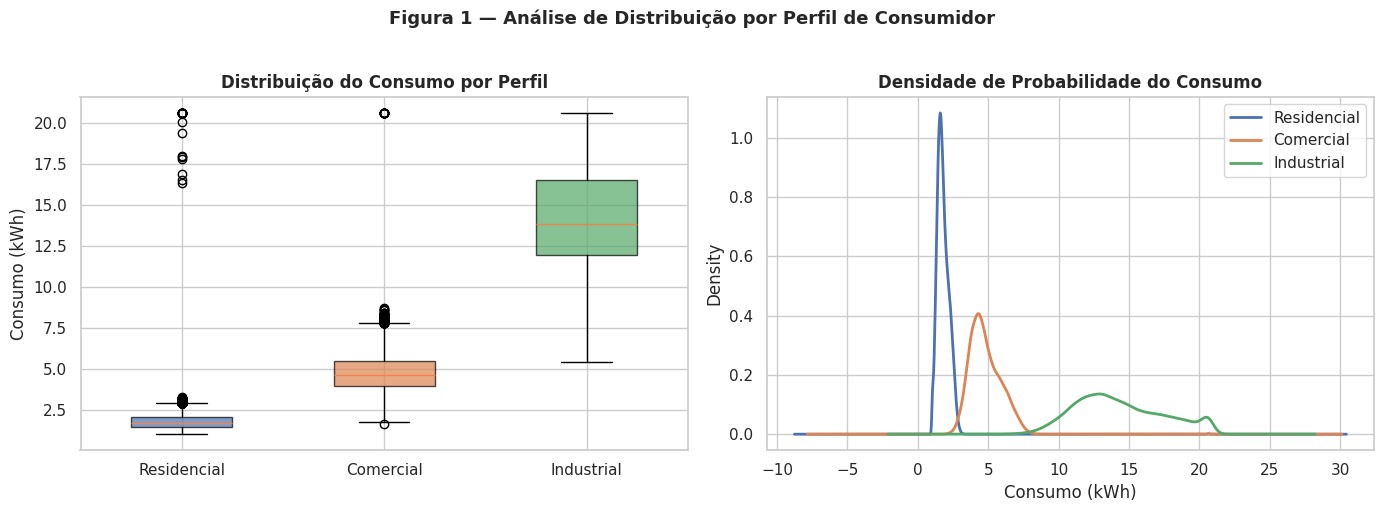

In [36]:
# Distribuição do consumo por perfil 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
cores = {'Residencial': '#4C72B0', 'Comercial': '#DD8452', 'Industrial': '#55A868'}
for perfil, cor in cores.items():
    subset = df[df['perfil'] == perfil]['consumo_kwh']
    axes[0].boxplot(subset, positions=[list(cores.keys()).index(perfil)],
                    widths=0.5, patch_artist=True,
                    boxprops=dict(facecolor=cor, alpha=0.7))
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(list(cores.keys()))
axes[0].set_title('Distribuição do Consumo por Perfil', fontweight='bold')
axes[0].set_ylabel('Consumo (kWh)')

# KDE
for perfil, cor in cores.items():
    subset = df[df['perfil'] == perfil]['consumo_kwh']
    subset.plot.kde(ax=axes[1], label=perfil, color=cor, linewidth=2)
axes[1].set_title('Densidade de Probabilidade do Consumo', fontweight='bold')
axes[1].set_xlabel('Consumo (kWh)')
axes[1].legend()

plt.suptitle('Figura 1 — Análise de Distribuição por Perfil de Consumidor',
             y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_distribuicao_perfil.png', dpi=150, bbox_inches='tight')
plt.show()

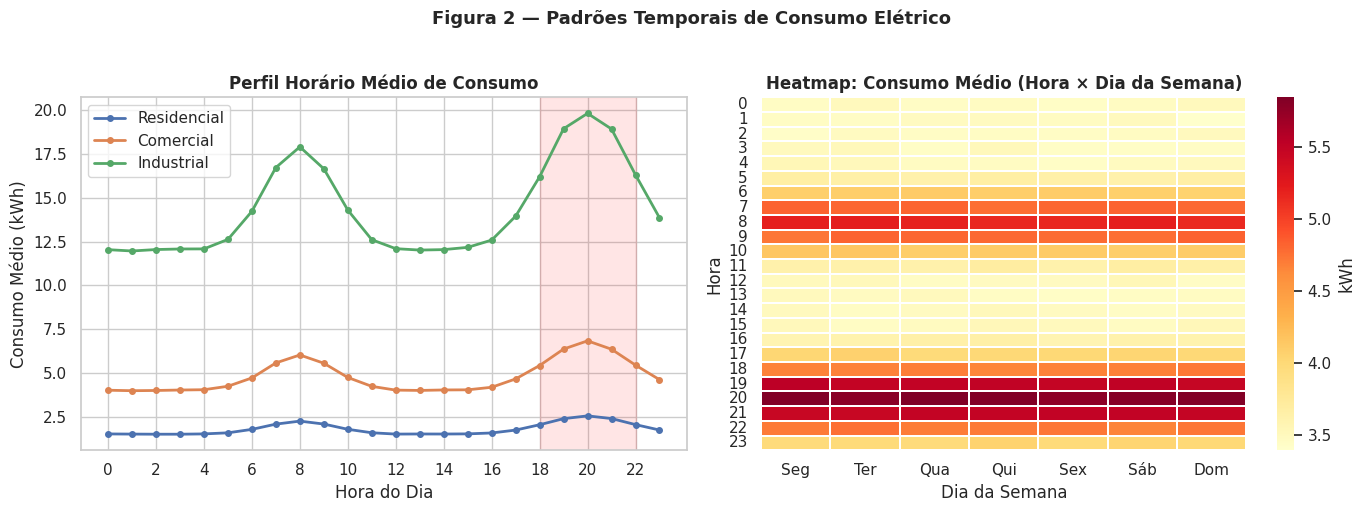

In [37]:
# Perfil horário de consumo 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

consumo_hora = df.groupby(['hora', 'perfil'])['consumo_kwh'].mean().reset_index()
for perfil, cor in cores.items():
    sub = consumo_hora[consumo_hora['perfil'] == perfil]
    axes[0].plot(sub['hora'], sub['consumo_kwh'], marker='o',
                 label=perfil, color=cor, linewidth=2, markersize=4)
axes[0].set_title('Perfil Horário Médio de Consumo', fontweight='bold')
axes[0].set_xlabel('Hora do Dia')
axes[0].set_ylabel('Consumo Médio (kWh)')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()
axes[0].axvspan(18, 22, alpha=0.1, color='red', label='Horário de Pico')

# Heatmap hora x dia da semana
ordem_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
nomes_dias = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']
pivot_heat = df.pivot_table(values='consumo_kwh',
                             index='hora', columns='dia_semana',
                             aggfunc='mean')[ordem_dias]
pivot_heat.columns = nomes_dias
sns.heatmap(pivot_heat, cmap='YlOrRd', ax=axes[1], linewidths=0.3, cbar_kws={'label': 'kWh'})
axes[1].set_title('Heatmap: Consumo Médio (Hora × Dia da Semana)', fontweight='bold')
axes[1].set_xlabel('Dia da Semana')
axes[1].set_ylabel('Hora')

plt.suptitle('Figura 2 — Padrões Temporais de Consumo Elétrico',
             y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_padroes_temporais.png', dpi=150, bbox_inches='tight')
plt.show()

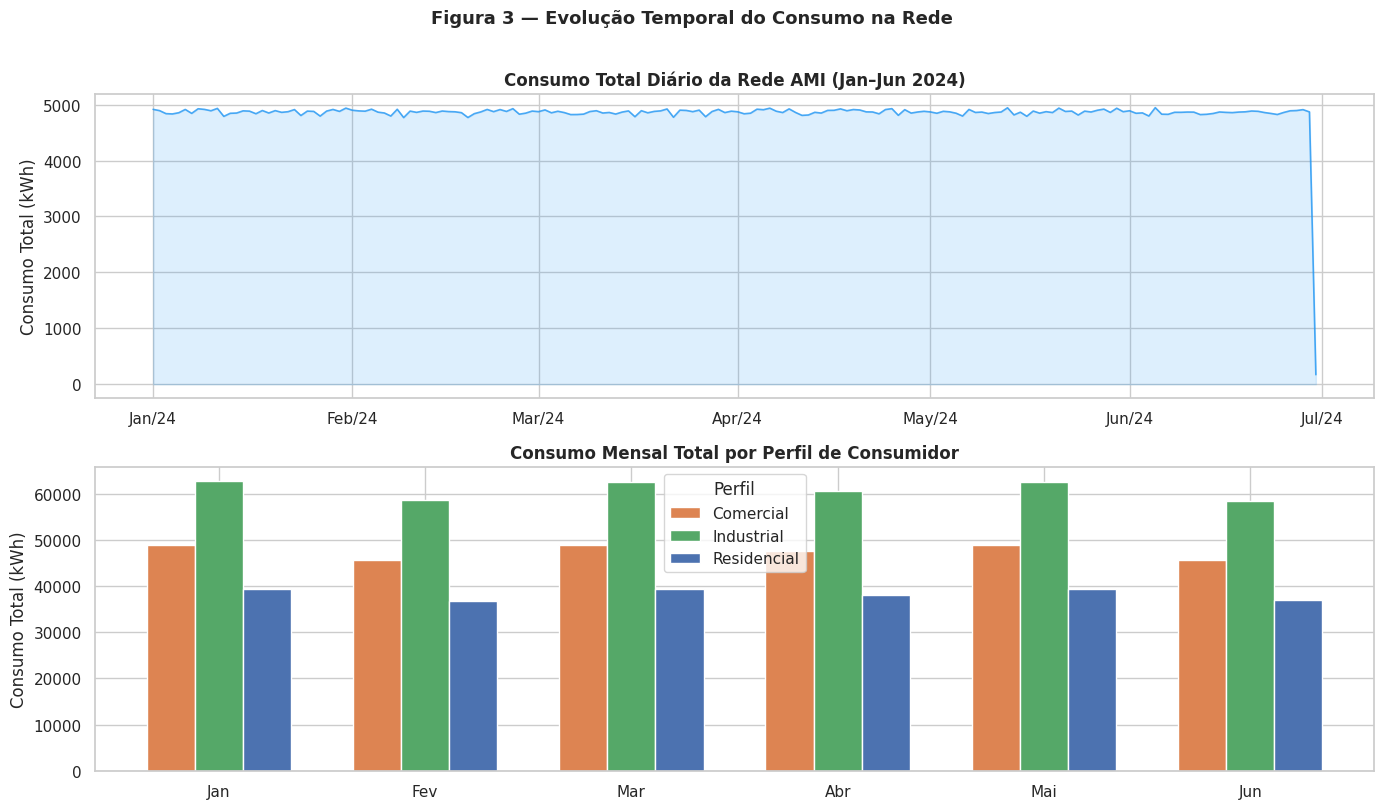

In [38]:
# Série temporal e consumo mensal 
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Série temporal diária (agregada)
serie_diaria = df.groupby(df['timestamp'].dt.date)['consumo_kwh'].sum()
axes[0].plot(pd.to_datetime(serie_diaria.index), serie_diaria.values,
             color='#2196F3', linewidth=1.2, alpha=0.8)
axes[0].fill_between(pd.to_datetime(serie_diaria.index), serie_diaria.values,
                      alpha=0.15, color='#2196F3')
axes[0].set_title('Consumo Total Diário da Rede AMI (Jan–Jun 2024)', fontweight='bold')
axes[0].set_ylabel('Consumo Total (kWh)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))

# Consumo mensal por perfil
consumo_mensal = df.groupby(['mes', 'perfil'])['consumo_kwh'].sum().reset_index()
nomes_mes = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun'}
consumo_mensal['mes_nome'] = consumo_mensal['mes'].map(nomes_mes)

pivot_mensal = consumo_mensal.pivot(index='mes_nome', columns='perfil', values='consumo_kwh')
pivot_mensal = pivot_mensal.reindex(['Jan','Fev','Mar','Abr','Mai','Jun'])
pivot_mensal.plot(kind='bar', ax=axes[1],
                   color=[cores[c] for c in pivot_mensal.columns],
                   width=0.7, edgecolor='white')
axes[1].set_title('Consumo Mensal Total por Perfil de Consumidor', fontweight='bold')
axes[1].set_ylabel('Consumo Total (kWh)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Perfil')

plt.suptitle('Figura 3 — Evolução Temporal do Consumo na Rede',
             y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_serie_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

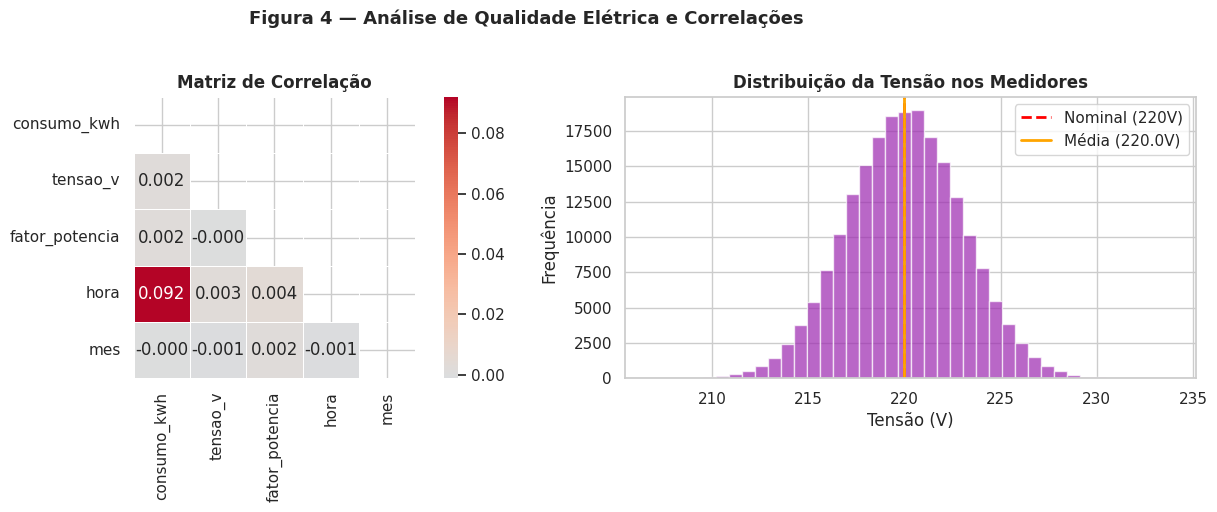

In [39]:
# Correlação e qualidade de tensão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlação entre variáveis numéricas
num_cols = ['consumo_kwh', 'tensao_v', 'fator_potencia', 'hora', 'mes']
corr = df[num_cols].corr()
mascara = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mascara, annot=True, fmt='.3f',
            cmap='coolwarm', center=0, ax=axes[0],
            linewidths=0.5, square=True)
axes[0].set_title('Matriz de Correlação', fontweight='bold')

# Distribuição de tensão (variação de qualidade)
axes[1].hist(df['tensao_v'], bins=40, color='#9C27B0', alpha=0.7, edgecolor='white')
axes[1].axvline(220, color='red', linestyle='--', linewidth=2, label='Nominal (220V)')
axes[1].axvline(df['tensao_v'].mean(), color='orange', linestyle='-',
                linewidth=2, label=f'Média ({df.tensao_v.mean():.1f}V)')
axes[1].set_title('Distribuição da Tensão nos Medidores', fontweight='bold')
axes[1].set_xlabel('Tensão (V)')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.suptitle('Figura 4 — Análise de Qualidade Elétrica e Correlações',
             y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_correlacao_qualidade.png', dpi=150, bbox_inches='tight')
plt.show()

## Documentação de Metadados do Dataset

In [40]:
metadados = {
    'nome_dataset'   : 'consumo_eletrico_ami_2024',
    'descricao'      : 'Leituras horárias de 50 medidores inteligentes AMI simulados',
    'periodo'        : f'{INICIO} a {FIM}',
    'frequencia'     : 'Horária (1H)',
    'qtd_registros'  : len(df),
    'qtd_medidores'  : N_MEDIDORES,
    'colunas': {
        'medidor_id'    : 'Identificador único do medidor (MED_001 ... MED_050)',
        'perfil'        : 'Categoria do consumidor: Residencial, Comercial, Industrial',
        'timestamp'     : 'Data e hora da leitura (datetime64)',
        'consumo_kwh'   : 'Consumo elétrico no período (kWh) — pré-processado',
        'tensao_v'      : 'Tensão elétrica medida (V)',
        'fator_potencia': 'Fator de potência (0 a 1)',
        'hora'          : 'Hora do dia extraída do timestamp (0–23)',
        'dia_semana'    : 'Nome do dia da semana',
        'mes'           : 'Mês (1–12)',
        'turno'         : 'Turno: Madrugada / Manhã / Tarde / Noite',
        'fim_semana'    : 'Booleano — True se Sábado ou Domingo'
    },
    'transformacoes_aplicadas': [
        'Remoção de duplicatas',
        'Remoção de valores negativos de consumo',
        'Winsorização (p0.5% - p99.5%) para outliers extremos',
        'Imputação de nulos com mediana por medidor',
        'Engenharia de features temporais'
    ],
    'qualidade_final': {
        'completude'     : '100%',
        'nulos_restantes': int(df.isna().sum().sum()),
        'registros_finais': len(df)
    }
}

import json
with open('metadados_dataset.json', 'w', encoding='utf-8') as f:
    json.dump(metadados, f, ensure_ascii=False, indent=2)

print('Metadados exportados para metadados_dataset.json')
print(json.dumps(metadados, ensure_ascii=False, indent=2))

Metadados exportados para metadados_dataset.json
{
  "nome_dataset": "consumo_eletrico_ami_2024",
  "descricao": "Leituras horárias de 50 medidores inteligentes AMI simulados",
  "periodo": "2024-01-01 a 2024-06-30",
  "frequencia": "Horária (1H)",
  "qtd_registros": 212846,
  "qtd_medidores": 50,
  "colunas": {
    "medidor_id": "Identificador único do medidor (MED_001 ... MED_050)",
    "perfil": "Categoria do consumidor: Residencial, Comercial, Industrial",
    "timestamp": "Data e hora da leitura (datetime64)",
    "consumo_kwh": "Consumo elétrico no período (kWh) — pré-processado",
    "tensao_v": "Tensão elétrica medida (V)",
    "fator_potencia": "Fator de potência (0 a 1)",
    "hora": "Hora do dia extraída do timestamp (0–23)",
    "dia_semana": "Nome do dia da semana",
    "mes": "Mês (1–12)",
    "turno": "Turno: Madrugada / Manhã / Tarde / Noite",
    "fim_semana": "Booleano — True se Sábado ou Domingo"
  },
  "transformacoes_aplicadas": [
    "Remoção de duplicatas",
    "

## Exportação do Dataset Limpo

In [41]:
df.to_csv('dataset_ami_limpo.csv', index=False, encoding='utf-8')
print(f'✅ Dataset limpo salvo: dataset_ami_limpo.csv')
print(f'   Shape final : {df.shape}')
print(f'   Tamanho     : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

✅ Dataset limpo salvo: dataset_ami_limpo.csv
   Shape final : (212846, 11)
   Tamanho     : 56.32 MB
